In [1]:
!pip -q install qiskit qiskit-aer matplotlib pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.2 MB/s eta 0:00:00


In [2]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display

sim = AerSimulator()
shots = 1024

In [3]:
patterns = [format(i, "03b") for i in range(8)]
print(patterns)

['000', '001', '010', '011', '100', '101', '110', '111']


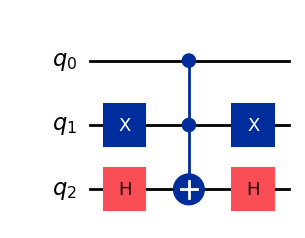

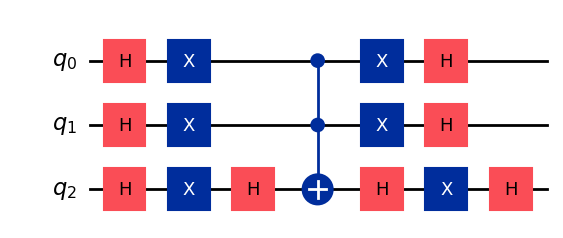

In [4]:
def oracle(target):
    qc = QuantumCircuit(3)
    # qiskit reads bits right to left, so reverse
    zeros = [i for i, b in enumerate(reversed(target)) if b == "0"]
    # X on the 0 bits so target becomes 111
    if zeros:
        qc.x(zeros)
    # CCZ = H + CCX + H, flips sign of 111 only
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)
    if zeros:
        qc.x(zeros)
    return qc


def diffuser():
    qc = QuantumCircuit(3)
    qc.h([0, 1, 2])
    qc.x([0, 1, 2])
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)
    qc.x([0, 1, 2])
    qc.h([0, 1, 2])
    return qc


display(oracle("101").draw("mpl"))
display(diffuser().draw("mpl"))

In [5]:
# pi/4 * sqrt(8) = 2.2 -> 2 rounds
iterations = int(np.pi / 4 * np.sqrt(8))
print(iterations)

2


In [6]:
target = input("target pattern: ").strip()

for p in patterns:
    if p == target:
        print(p, "<- target")
    else:
        print(p)

target pattern: 101
000
001
010
011
100
101 <- target
110
111


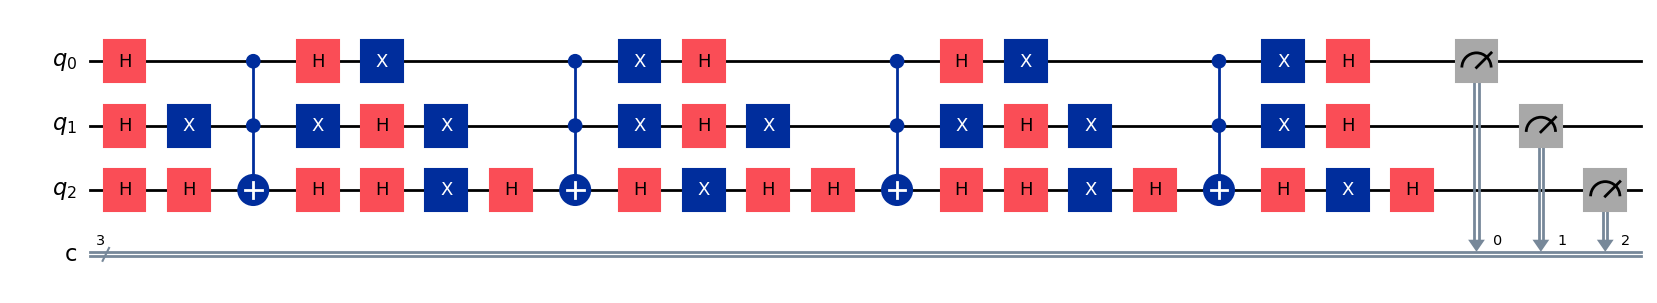

In [7]:
qc = QuantumCircuit(3, 3)
qc.h([0, 1, 2])

for _ in range(iterations):
    qc.compose(oracle(target), inplace=True)
    qc.compose(diffuser(), inplace=True)

qc.measure([0, 1, 2], [0, 1, 2])
display(qc.draw("mpl", fold=-1))

In [8]:
# amplitudes after each step, target goes negative after oracle then grows
test = QuantumCircuit(3)
test.h([0, 1, 2])
print("after H      ", np.round(Statevector.from_instruction(test).data.real, 3))
for k in range(iterations):
    test.compose(oracle(target), inplace=True)
    print("after oracle ", np.round(Statevector.from_instruction(test).data.real, 3))
    test.compose(diffuser(), inplace=True)
    print("after diff   ", np.round(Statevector.from_instruction(test).data.real, 3))

after H       [0.354 0.354 0.354 0.354 0.354 0.354 0.354 0.354]
after oracle  [ 0.354  0.354  0.354  0.354  0.354 -0.354  0.354  0.354]
after diff    [-0.177 -0.177 -0.177 -0.177 -0.177 -0.884 -0.177 -0.177]
after oracle  [-0.177 -0.177 -0.177 -0.177 -0.177  0.884 -0.177 -0.177]
after diff    [-0.088 -0.088 -0.088 -0.088 -0.088  0.972 -0.088 -0.088]


{'001': 7, '100': 8, '110': 8, '000': 5, '010': 9, '011': 7, '111': 6, '101': 974}


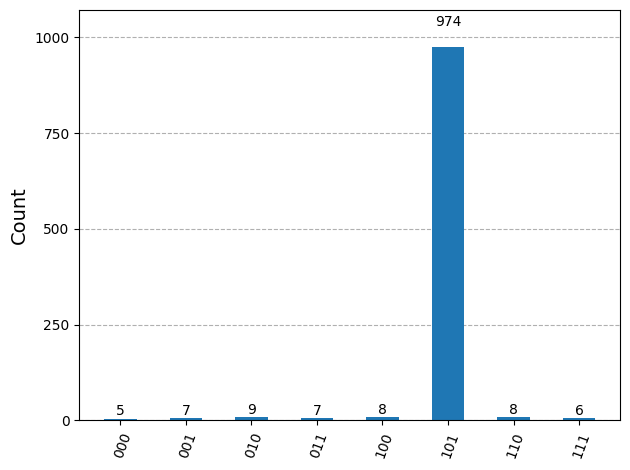

target : 101
found  : 101
hits   : 974 / 1024


In [9]:
counts = sim.run(transpile(qc, sim), shots=shots).result().get_counts()
print(counts)
display(plot_histogram(counts))

found = max(counts, key=counts.get)
print("target :", target)
print("found  :", found)
print("hits   :", counts.get(target, 0), "/", shots)

In [10]:
# same code, only target changes
for t in ["000", "011", "101", "110"]:
    c = QuantumCircuit(3, 3)
    c.h([0, 1, 2])
    for _ in range(iterations):
        c.compose(oracle(t), inplace=True)
        c.compose(diffuser(), inplace=True)
    c.measure([0, 1, 2], [0, 1, 2])
    res = sim.run(transpile(c, sim), shots=shots).result().get_counts()
    print(t, "->", max(res, key=res.get), res.get(t, 0))

000 -> 000 981
011 -> 011 981
101 -> 101 965
110 -> 110 964


In [12]:

  - Initialization: Applying Hadamard gates to all 3 qubits creates an equal superposition of all 8 state patterns, each with an amplitude of 1/sqrt{8}.
  - Oracle (Phase Marking): Applying X gates on the '0' bits, a CCZ gate, and un-computing with X gates flips the sign of only the target state. This phase shift marks the target without altering measurement probabilities.
  - Diffuser (Inversion About the Mean): The diffuser flips all amplitudes around the average, using constructive interference to boost the target amplitude while cancelling out the rest.
  - Amplitude Amplification: Running two iterations of the oracle and diffuser amplifies the target state probability from 12.5% to ~94%.
  - Measurement: Running 1024 shots on AerSimulator consistently identifies the target pattern with the highest frequency.

SyntaxError: illegal target for annotation (4233650673.py, line 1)